# SKIPP'D Solar Nowcast — Web Interface

A Gradio app serving your trained SUNSET model. **Run the single cell below.**

**Includes:** clickable test-sample gallery (with actual kW + error), a greyscale toggle, a guard that rejects cartoons/drawings/non-photos, negative-power clamping to 0, and an optional 15-min forecast tab.

**Prerequisite:** the nowcast notebook must have finished training and saved its `.keras` checkpoints to `SKIPPD/model_output/SUNSET_nowcast_run/`.

**Notes:** *Greyscale* desaturates but keeps 3 channels to match the model's input; expect predictions to get slightly *worse*, since colour carries real signal. The non-photo guard is a heuristic — it blocks obvious cartoons but isn't a perfect classifier.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================================
#  SKIPP'D Solar Nowcast — Gradio web interface (single self-contained cell)
#  Features:
#   - loads your trained SUNSET nowcast ensemble from Drive
#   - clickable test-sample gallery with actual kW + error
#   - greyscale toggle (desaturate but keep 3 channels)
#   - rejects cartoons / drawings / non-photos
#   - clamps physically-impossible negative power to 0
#   - optional 15-min forecast tab (shown only if its files exist)
# ============================================================================
!pip install -q gradio

import os, glob, traceback
import numpy as np
from PIL import Image
import gradio as gr
import tensorflow as tf
from tensorflow import keras

BASE          = "/content/drive/MyDrive/SKIPPD"
NOWCAST_DIR   = os.path.join(BASE, "model_output", "SUNSET_nowcast_run")
FORECAST_DIR  = os.path.join(BASE, "model_output", "SUNSET_forecast_run")
HDF5_PATH     = os.path.join(BASE, "images_pv_processed.hdf5")
FORECAST_NPZ  = os.path.join(BASE, "forecast_samples.npz")

# mount Drive (harmless if already mounted)
try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
except Exception:
    pass

# ----------------------------------------------------------------------------
# 1. LOAD THE NOWCAST ENSEMBLE (once, at startup)
# ----------------------------------------------------------------------------
def load_nowcast_models():
    models = []
    if os.path.isdir(NOWCAST_DIR):
        paths = sorted(glob.glob(os.path.join(NOWCAST_DIR, "repetition_*",
                                              "best_model_repitition_*.keras")))
        for p in paths:
            try:
                models.append(keras.models.load_model(p))
                print("  loaded", os.path.relpath(p, BASE))
            except Exception as e:
                print("  FAILED to load", p, "->", e)
    return models

print("Loading nowcast ensemble ...")
try:
    NOWCAST_MODELS = load_nowcast_models()
except Exception:
    NOWCAST_MODELS = []
    traceback.print_exc()
print(f"Nowcast models loaded: {len(NOWCAST_MODELS)}")

# ----------------------------------------------------------------------------
# 2. LOAD A FEW TEST SAMPLES (for the "try an example" gallery)
# ----------------------------------------------------------------------------
SAMPLE_IMAGES, SAMPLE_ACTUALS = [], []
try:
    import h5py
    with h5py.File(HDF5_PATH, "r") as f:
        n = f["test/images_log"].shape[0]
        k = min(12, n)
        idx = sorted(np.random.default_rng(0).choice(n, size=k, replace=False).tolist())
        SAMPLE_IMAGES  = [f["test/images_log"][i].astype("uint8") for i in idx]
        SAMPLE_ACTUALS = [float(f["test/pv_log"][i]) for i in idx]
    print(f"Loaded {len(SAMPLE_IMAGES)} test samples for the gallery.")
except Exception as e:
    print("Could not load test samples (gallery will be empty):", e)

# ----------------------------------------------------------------------------
# 3. NON-PHOTO GUARD
#    Cheap heuristic to reject cartoons / drawings / screenshots. Real photos
#    have many colours, fine texture, and few large flat regions.
# ----------------------------------------------------------------------------
def looks_like_photo(img):
    """Return (ok: bool, reason: str)."""
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)
    rgb = img.convert("RGB")
    arr = np.asarray(rgb.resize((128, 128))).astype("float32")

    # (1) colour variety — cartoons use few distinct colours
    small = (np.asarray(rgb.resize((64, 64))) // 16)          # coarse quantise
    n_colours = len(np.unique(small.reshape(-1, 3), axis=0))

    # (2) texture — natural photos have lots of fine local variation
    grey = arr.mean(axis=2)
    texture = (np.abs(np.diff(grey, axis=1)).mean() +
               np.abs(np.diff(grey, axis=0)).mean()) / 2.0

    # (3) flat-region dominance — cartoons have big uniform patches
    flat = (np.abs(np.diff(grey, axis=1)) < 2).mean()

    if n_colours < 60:
        return False, f"too few distinct colours ({n_colours}) — looks like a drawing/cartoon"
    if texture < 1.5:
        return False, "too little texture — looks flat/illustrated, not a photo"
    if flat > 0.85:
        return False, "mostly flat regions — looks like a cartoon or graphic"
    return True, ""

# ----------------------------------------------------------------------------
# 4. PREPROCESS + PREDICT
#    Model needs 64x64x3. "Greyscale" = desaturate but keep 3 identical channels.
#    Models contain an internal Rescaling(1/255), so feed raw uint8 [0,255].
#    PV power is physically >= 0, so negative predictions are clamped to 0.
# ----------------------------------------------------------------------------
def preprocess(img, to_grey=False):
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)
    img = img.convert("RGB")
    if to_grey:
        img = img.convert("L").convert("RGB")
    img = img.resize((64, 64))
    return np.asarray(img, dtype=np.uint8)[None, ...]

def predict_kw(img, to_grey=False):
    if not NOWCAST_MODELS:
        return None
    x = preprocess(img, to_grey=to_grey)
    preds = [float(np.squeeze(m.predict(x, verbose=0))) for m in NOWCAST_MODELS]
    return max(0.0, float(np.mean(preds)))       # clamp negatives to 0

def format_result(pred, actual=None, grey=False):
    if pred is None:
        return ("<div style='color:#b83a4b;font-size:16px'>No trained models found.<br>"
                "Run the <b>SUNSET nowcast</b> notebook to train and save the ensemble first.</div>")
    mode = " (greyscale input)" if grey else ""
    html = (f"<div style='font-size:15px;color:#666'>Predicted PV output{mode}</div>"
            f"<div style='font-size:52px;font-weight:700;color:#67AFD2'>{pred:.2f} "
            f"<span style='font-size:24px;color:#999'>kW</span></div>")
    if actual is not None:
        html += (f"<div style='font-size:16px;margin-top:8px'>"
                 f"Actual: <b>{actual:.2f} kW</b> &nbsp;|&nbsp; "
                 f"Absolute error: <b>{abs(pred-actual):.2f} kW</b></div>")
    return html

def reject_html(reason):
    return (f"<div style='color:#b83a4b;font-size:16px'>"
            f"&#9888; This doesn't look like a real sky photo.<br>"
            f"<span style='font-size:13px;color:#888'>{reason}</span><br>"
            f"Please upload an actual photograph of the sky.</div>")

# ----------------------------------------------------------------------------
# 5. EVENT HANDLERS
# ----------------------------------------------------------------------------
def on_upload(img, grey):
    if img is None:
        return "<div style='color:#999'>Upload a sky image or click a sample below.</div>"
    ok, reason = looks_like_photo(img)          # block cartoons/drawings
    if not ok:
        return reject_html(reason)
    try:
        return format_result(predict_kw(img, to_grey=grey), actual=None, grey=grey)
    except Exception:
        return f"<pre style='color:#b83a4b'>Prediction error:\n{traceback.format_exc()}</pre>"

def on_sample_select(evt: gr.SelectData, grey):
    # gallery images are real test photos, so no photo-guard needed here
    try:
        i = evt.index
        return format_result(predict_kw(SAMPLE_IMAGES[i], to_grey=grey),
                             actual=SAMPLE_ACTUALS[i], grey=grey)
    except Exception:
        return f"<pre style='color:#b83a4b'>{traceback.format_exc()}</pre>"

# ----------------------------------------------------------------------------
# 6. OPTIONAL — 15-MIN FORECAST (loaded only if its files exist)
# ----------------------------------------------------------------------------
FC = {"models": [], "Xi": None, "Xp": None, "y": None}
try:
    if os.path.isfile(FORECAST_NPZ) and os.path.isdir(FORECAST_DIR):
        d = np.load(FORECAST_NPZ)
        Xi = np.transpose(d["Xi_test"], (0, 2, 3, 1, 4))
        FC["Xi"] = Xi.reshape(Xi.shape[0], Xi.shape[1], Xi.shape[2], -1)   # (N,64,64,48)
        FC["Xp"] = d["Xp_test"].astype("float32")
        FC["y"]  = d["y_test"].astype("float32")
        for p in sorted(glob.glob(os.path.join(FORECAST_DIR, "best_model_rep_*.keras"))):
            try:
                FC["models"].append(keras.models.load_model(p))
            except Exception as e:
                print("  forecast model failed:", e)
        print(f"Forecast ready: {len(FC['models'])} models, {len(FC['y'])} test sequences.")
except Exception as e:
    print("Forecast tab disabled:", e)

def forecast_predict(i):
    if not FC["models"] or FC["Xi"] is None:
        return ("<div style='color:#999'>Forecast model/data not available. "
                "Run notebook 3 and the forecast training notebook first.</div>")
    i = int(i)
    preds = [float(np.squeeze(m.predict([FC["Xi"][i:i+1], FC["Xp"][i:i+1]], verbose=0)))
             for m in FC["models"]]
    pred    = max(0.0, float(np.mean(preds)))          # clamp negatives to 0
    actual  = float(FC["y"][i])
    persist = max(0.0, float(FC["Xp"][i, -1]))
    return (f"<div style='font-size:15px;color:#666'>Predicted PV 15 min ahead</div>"
            f"<div style='font-size:46px;font-weight:700;color:#B83A4B'>{pred:.2f} "
            f"<span style='font-size:22px;color:#999'>kW</span></div>"
            f"<div style='font-size:16px;margin-top:8px'>"
            f"Actual: <b>{actual:.2f} kW</b> &nbsp;|&nbsp; error <b>{abs(pred-actual):.2f}</b><br>"
            f"Persistence baseline: {persist:.2f} kW &nbsp;|&nbsp; "
            f"error {abs(persist-actual):.2f}</div>")

# ----------------------------------------------------------------------------
# 7. BUILD THE INTERFACE
# ----------------------------------------------------------------------------
with gr.Blocks(title="SKIPP'D Solar Nowcast") as demo:
    gr.Markdown("## SKIPP'D Solar Nowcast — sky image to PV power")
    gr.Markdown("This model estimates current solar panel output from a photo of the sky. "
                "_Predictions are calibrated to the Stanford fisheye sky camera + PV system; "
                "your own photos will produce a number but not a validated one._")

    with gr.Tab("Nowcast"):
        with gr.Row():
            with gr.Column():
                inp  = gr.Image(type="pil", label="Sky image (upload any size)")
                grey = gr.Checkbox(value=False,
                                   label="Convert to greyscale before predicting")
                gr.Markdown("**Or click a test sample (known actual kW):**")
                gallery = gr.Gallery(value=[im for im in SAMPLE_IMAGES],
                                     columns=6, height="auto", label="Test samples")
            with gr.Column():
                out = gr.HTML("<div style='color:#999'>Upload a sky image or click a sample.</div>")

        inp.change(on_upload, inputs=[inp, grey], outputs=out)
        grey.change(on_upload, inputs=[inp, grey], outputs=out)
        gallery.select(on_sample_select, inputs=grey, outputs=out)

    if FC["models"]:
        with gr.Tab("15-min Forecast"):
            with gr.Row():
                with gr.Column():
                    sl  = gr.Slider(0, len(FC["y"]) - 1, step=1, value=0,
                                    label="Test sequence #")
                    btn = gr.Button("Predict 15-min ahead")
                with gr.Column():
                    fout = gr.HTML()
            btn.click(forecast_predict, inputs=sl, outputs=fout)
            sl.change(forecast_predict, inputs=sl, outputs=fout)

# ----------------------------------------------------------------------------
# 8. LAUNCH (public shareable URL)
# ----------------------------------------------------------------------------
demo.launch(share=True)


Loading nowcast ensemble ...
  loaded model_output/SUNSET_nowcast_run/repetition_1/best_model_repitition_1.keras
  loaded model_output/SUNSET_nowcast_run/repetition_2/best_model_repitition_2.keras
  loaded model_output/SUNSET_nowcast_run/repetition_3/best_model_repitition_3.keras
Nowcast models loaded: 3
Loaded 12 test samples for the gallery.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ea63c2b92d57c7e1bc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Loading 3 models ...



  NOWCAST TEST METRICS  (n = 427)
  MAE   :   2.347 kW
  RMSE  :   3.292 kW
  MBE   :   0.126 kW   (bias; ~0 good)
  R^2   :   0.518
  Corr  :   0.735
  nRMSE :  12.49 %
  nMAE  :   8.90 %
  Skill :  30.54 %   (vs mean baseline)
  PV range: 0.0 .. 26.4 kW


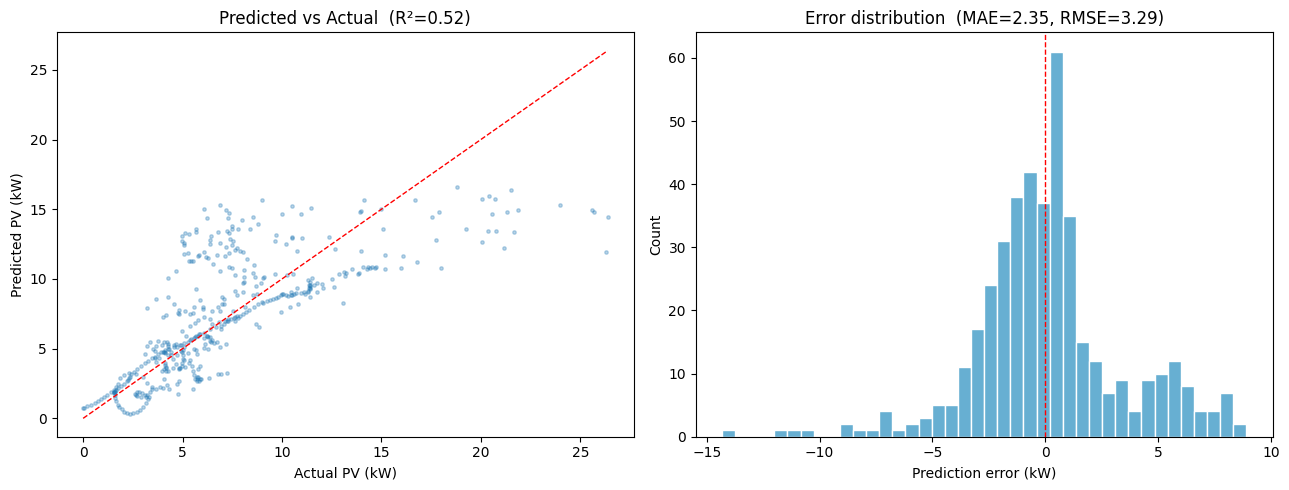

In [3]:
# ============================================================================
#  Nowcast model — full test-set evaluation metrics
# ============================================================================
import os, glob
import numpy as np, h5py
import matplotlib.pyplot as plt
from tensorflow import keras

BASE        = "/content/drive/MyDrive/SKIPPD"
NOWCAST_DIR = os.path.join(BASE, "model_output", "SUNSET_nowcast_run")
HDF5_PATH   = os.path.join(BASE, "images_pv_processed.hdf5")

# --- load test data ---
with h5py.File(HDF5_PATH, "r") as f:
    X_test = f["test/images_log"][...]
    y_test = f["test/pv_log"][...].astype("float32")

# --- load ensemble & predict ---
paths = sorted(glob.glob(os.path.join(NOWCAST_DIR, "repetition_*",
                                      "best_model_repitition_*.keras")))
assert paths, "No trained models found — run the nowcast training notebook first."
print(f"Loading {len(paths)} models ...")
preds = [np.squeeze(keras.models.load_model(p).predict(X_test, batch_size=200, verbose=0))
         for p in paths]
y_pred = np.clip(np.mean(preds, axis=0), 0, None)

# --- metrics ---
err   = y_pred - y_test
mae   = np.mean(np.abs(err))
rmse  = np.sqrt(np.mean(err**2))
mbe   = np.mean(err)
r2    = 1 - np.sum(err**2)/np.sum((y_test - y_test.mean())**2)
corr  = np.corrcoef(y_test, y_pred)[0, 1]
rng   = y_test.max() - y_test.min()
nrmse = 100*rmse/rng
nmae  = 100*mae/rng
skill = 100*(1 - rmse/np.sqrt(np.mean((y_test - y_test.mean())**2)))

print("\n" + "="*46)
print("  NOWCAST TEST METRICS  (n = {:,})".format(len(y_test)))
print("="*46)
print(f"  MAE   : {mae:7.3f} kW")
print(f"  RMSE  : {rmse:7.3f} kW")
print(f"  MBE   : {mbe:7.3f} kW   (bias; ~0 good)")
print(f"  R^2   : {r2:7.3f}")
print(f"  Corr  : {corr:7.3f}")
print(f"  nRMSE : {nrmse:6.2f} %")
print(f"  nMAE  : {nmae:6.2f} %")
print(f"  Skill : {skill:6.2f} %   (vs mean baseline)")
print(f"  PV range: {y_test.min():.1f} .. {y_test.max():.1f} kW")
print("="*46)

# --- plots ---
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, y_pred, s=6, alpha=0.3)
lim = [0, max(y_test.max(), y_pred.max())]
ax[0].plot(lim, lim, 'r--', lw=1)
ax[0].set_xlabel("Actual PV (kW)"); ax[0].set_ylabel("Predicted PV (kW)")
ax[0].set_title(f"Predicted vs Actual  (R\u00b2={r2:.2f})")
ax[1].hist(err, bins=40, color="#67AFD2", edgecolor="white")
ax[1].axvline(0, color="r", ls="--", lw=1)
ax[1].set_xlabel("Prediction error (kW)"); ax[1].set_ylabel("Count")
ax[1].set_title(f"Error distribution  (MAE={mae:.2f}, RMSE={rmse:.2f})")
plt.tight_layout(); plt.show()

METRICS MATRIX
            MAE   RMSE    MBE     R2   Corr  Skill%
model_1   2.749  3.661 -0.371  0.403  0.707  22.763
model_2   2.324  3.508 -0.567  0.452  0.700  25.987
model_3   2.997  4.064  1.340  0.265  0.729  14.258
ENSEMBLE  2.339  3.288  0.134  0.519  0.735  30.620

CONFUSION MATRIX (bin edges kW: [ 0.   5.   7.7 26.4]) | bin accuracy = 71.0%
               pred Low  pred Medium  pred High
actual Low          113           21          8
actual Medium        29           55         58
actual High           0            8        135


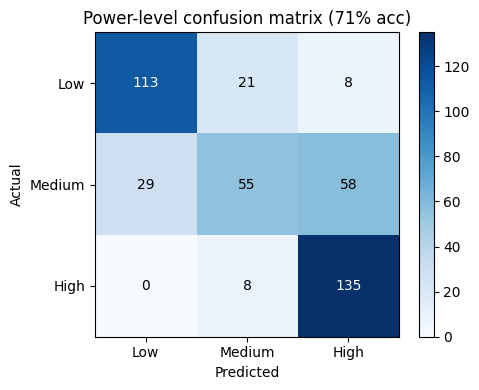

In [4]:
# ============================================================================
#  Nowcast — Evaluation Matrix (metrics table + binned confusion matrix)
# ============================================================================
import os, glob
import numpy as np, pandas as pd, h5py
import matplotlib.pyplot as plt
from tensorflow import keras

BASE        = "/content/drive/MyDrive/SKIPPD"
NOWCAST_DIR = os.path.join(BASE, "model_output", "SUNSET_nowcast_run")
HDF5_PATH   = os.path.join(BASE, "images_pv_processed.hdf5")

with h5py.File(HDF5_PATH, "r") as f:
    X_test = f["test/images_log"][...]
    y_test = f["test/pv_log"][...].astype("float32")

paths = sorted(glob.glob(os.path.join(NOWCAST_DIR, "repetition_*",
                                      "best_model_repitition_*.keras")))
assert paths, "No trained models found — train the nowcast notebook first."

# predictions for every model + the ensemble
per_model = [np.clip(np.squeeze(keras.models.load_model(p).predict(X_test, batch_size=200, verbose=0)), 0, None)
             for p in paths]
ensemble  = np.clip(np.mean(per_model, axis=0), 0, None)

def metrics(y_true, y_pred):
    e = y_pred - y_true
    rmse = np.sqrt(np.mean(e**2))
    base = np.sqrt(np.mean((y_true - y_true.mean())**2))
    return {
        "MAE":   np.mean(np.abs(e)),
        "RMSE":  rmse,
        "MBE":   np.mean(e),
        "R2":    1 - np.sum(e**2)/np.sum((y_true - y_true.mean())**2),
        "Corr":  np.corrcoef(y_true, y_pred)[0, 1],
        "Skill%": 100*(1 - rmse/base),
    }

# ---- 1. METRICS MATRIX (rows = each model + ensemble, cols = metrics) ----
rows = {f"model_{i+1}": metrics(y_test, p) for i, p in enumerate(per_model)}
rows["ENSEMBLE"] = metrics(y_test, ensemble)
metrics_matrix = pd.DataFrame(rows).T.round(3)
print("METRICS MATRIX")
print(metrics_matrix.to_string())

# ---- 2. CONFUSION MATRIX (bin continuous kW into Low / Medium / High) ----
edges  = np.quantile(y_test, [0, 1/3, 2/3, 1.0])          # tertile thresholds
labels = ["Low", "Medium", "High"]
def to_bin(v): return np.clip(np.digitize(v, edges[1:-1]), 0, 2)

true_bin = to_bin(y_test)
pred_bin = to_bin(ensemble)

cm = np.zeros((3, 3), dtype=int)
for t, p in zip(true_bin, pred_bin):
    cm[t, p] += 1
cm_df = pd.DataFrame(cm, index=[f"actual {l}" for l in labels],
                         columns=[f"pred {l}" for l in labels])
bin_acc = np.trace(cm) / cm.sum()
print(f"\nCONFUSION MATRIX (bin edges kW: {np.round(edges,1)}) | bin accuracy = {bin_acc:.1%}")
print(cm_df.to_string())

# ---- plot the confusion matrix ----
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Power-level confusion matrix ({bin_acc:.0%} acc)")
for t in range(3):
    for p in range(3):
        ax.text(p, t, cm[t, p], ha="center", va="center",
                color="white" if cm[t, p] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()